# Paper-Style Simulation Reproduction

這份 notebook 會建立一組 synthetic spatial dataset，並比較 Ordinary Kriging、Machine Learning ensemble 與 weighted Fusion model。目標是用較小規模的實驗復現 combined Machine Learning + Kriging paper 的方法邏輯，方便放進期末報告。

## 1. 選擇 Simulation Case

先執行第一份 notebook 診斷真實 weather data，再把下方 `CASE_TYPE` 設成最接近的 behavior：`gaussian`、`non_stationary`、`trend` 或 `skewed_lognormal`。這樣報告會聚焦在和你的資料最相關的 case。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from pykrige.ok import OrdinaryKriging

sns.set_theme(style='whitegrid')
rng = np.random.default_rng(42)
CASE_TYPE = 'non_stationary'
N = 450
print({'case_type': CASE_TYPE, 'n': N})


{'case_type': 'non_stationary', 'n': 450}


## 2. 產生 Synthetic Spatial Data

synthetic field 代表未知的 true spatial process。不同公式會產生不同 behavior，例如 trend case 含有 large-scale coordinate trend，而 lognormal case 會在 exponentiation 後呈現 skewed distribution。

,x,y,z
0,0.773956,0.042351,0.507791
1,0.438878,0.884146,-0.521651
2,0.858598,0.709578,-0.085382
3,0.697368,0.173128,-1.202070
4,0.094177,0.091721,1.002208


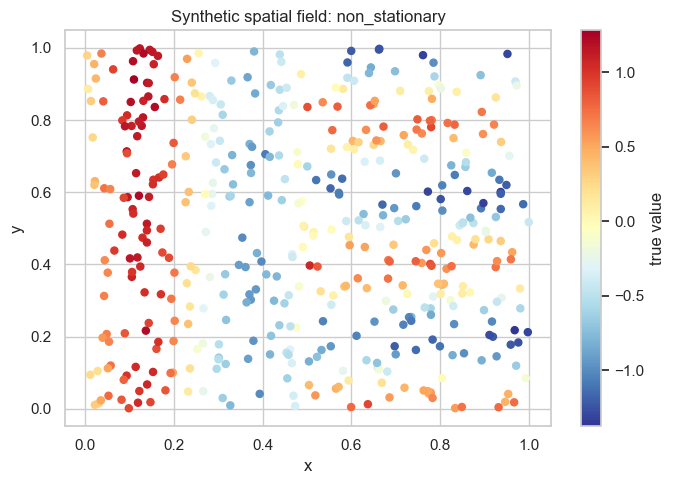

In [2]:
def generate_field(case_type, n):
    x = rng.uniform(0, 1, n)
    y = rng.uniform(0, 1, n)
    noise = rng.normal(0, 0.08, n)
    if case_type == 'gaussian':
        z = 2.0 + np.sin(2*np.pi*x) * 0.4 + np.cos(2*np.pi*y) * 0.3 + noise
    elif case_type == 'trend':
        z = 1.0 + 1.4*x - 0.8*y + 0.25*np.sin(4*np.pi*x*y) + noise
    elif case_type == 'skewed_lognormal':
        base = 0.4 + 0.7*np.sin(2*np.pi*x) + 0.5*np.cos(2*np.pi*y) + noise
        z = np.exp(base)
    else:
        left = np.sin(4*np.pi*x) + 0.2*y
        right = np.cos(5*np.pi*y) - 0.3*x
        z = np.where(x < 0.5, left, right) + noise
    return pd.DataFrame({'x': x, 'y': y, 'z': z})

sim = generate_field(CASE_TYPE, N)
display(sim.head())
plt.figure(figsize=(7, 5))
plt.scatter(sim['x'], sim['y'], c=sim['z'], cmap='RdYlBu_r', s=26)
plt.colorbar(label='true value')
plt.title(f'Synthetic spatial field: {CASE_TYPE}')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()

## 3. 訓練 Ordinary Kriging 與 Paper-Style Super Learner

這個 reproduction 對照 paper 的 model set：Kriging 使用 Ordinary Kriging，ML 使用 Super Learner-style stacking ensemble。base learners 包含 SVR、GBM、KNN、RF、Bagging、NN、ExtraTrees、DecisionTree 與 AdaBoost。這一節會先輸出每個 base learner 的 RMSE/MAE/R²，再輸出 meta learner 給各 base learner 的 stacking weight，最後形成 `Z_ML(u)`。


In [3]:
def ordinary_kriging_predict(train_xy, train_y, target_xy, variogram_model='spherical'):
    ok = OrdinaryKriging(
        train_xy[:, 0],
        train_xy[:, 1],
        train_y,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False,
    )
    pred, var = ok.execute('points', target_xy[:, 0], target_xy[:, 1])
    return np.asarray(pred, dtype=float), np.asarray(var, dtype=float)


def build_paper_super_learner(random_state=42):
    base_models = [
        ('SVR', SVR(kernel='rbf', gamma='scale', C=1e4, epsilon=0.01)),
        ('GBM', GradientBoostingRegressor(learning_rate=0.25, n_estimators=1000, min_samples_split=4, random_state=random_state)),
        ('KNN', KNeighborsRegressor(n_neighbors=2, p=2)),
        ('RF', RandomForestRegressor(n_estimators=2000, max_depth=None, min_samples_split=2, random_state=random_state, n_jobs=-1)),
        ('BAG', BaggingRegressor(n_estimators=3000, max_features=1.0, random_state=random_state, n_jobs=-1)),
        ('NN', MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', solver='adam', batch_size=80, max_iter=400, random_state=random_state)),
        ('EXT', ExtraTreesRegressor(n_estimators=2500, random_state=random_state, n_jobs=-1)),
        ('DT', DecisionTreeRegressor(max_depth=14, random_state=random_state)),
        ('ADA', AdaBoostRegressor(n_estimators=700, random_state=random_state)),
    ]
    return StackingRegressor(
        estimators=base_models,
        final_estimator=LinearRegression(),
        cv=5,
        n_jobs=-1,
        passthrough=False,
    )

train, test = train_test_split(sim, test_size=0.35, random_state=42)
X_train = train[['x', 'y']].to_numpy()
y_train = train['z'].to_numpy()
X_test = test[['x', 'y']].to_numpy()
y_test = test['z'].to_numpy()

kr_pred, kr_var = ordinary_kriging_predict(X_train, y_train, X_test)

super_learner = build_paper_super_learner(random_state=42)
super_learner.fit(X_train, y_train)
ml_pred = super_learner.predict(X_test)

def metric_row(name, pred):
    return {'model': name, 'RMSE': mean_squared_error(y_test, pred)**0.5, 'MAE': mean_absolute_error(y_test, pred), 'R2': r2_score(y_test, pred)}

base_results = []
for name, estimator in super_learner.named_estimators_.items():
    pred = estimator.predict(X_test)
    base_results.append(metric_row(name, pred))
base_results = pd.DataFrame(base_results).sort_values('RMSE')
display(base_results)

meta_weights = pd.DataFrame({
    'base_learner': list(super_learner.named_estimators_.keys()),
    'stacking_weight': super_learner.final_estimator_.coef_,
})
meta_weights['abs_weight'] = meta_weights['stacking_weight'].abs()
meta_weights = meta_weights.sort_values('abs_weight', ascending=False)
display(meta_weights)

pd.DataFrame([metric_row('Ordinary Kriging', kr_pred), metric_row('Super Learner', ml_pred)])


,model,RMSE,MAE,R2
0,SVR,0.159617,0.108020,0.952026
6,EXT,0.164985,0.124840,0.948746
4,BAG,0.188868,0.122363,0.932833
3,RF,0.189339,0.122801,0.932497
1,GBM,0.215374,0.160880,0.912656
2,KNN,0.246714,0.182072,0.885388
7,DT,0.247950,0.157666,0.884237
8,ADA,0.446949,0.355554,0.623851
5,NN,0.536349,0.420307,0.458326


,base_learner,stacking_weight,abs_weight
4,BAG,2.119789,2.119789
3,RF,-1.995287,1.995287
6,EXT,0.481089,0.481089
0,SVR,0.251445,0.251445
1,GBM,0.225022,0.225022
8,ADA,-0.187333,0.187333
7,DT,0.090077,0.090077
2,KNN,0.010736,0.010736
5,NN,-0.006914,0.006914


,model,RMSE,MAE,R2
0,Ordinary Kriging,0.365743,0.312855,0.748119
1,Super Learner,0.145912,0.105957,0.959911


## 4. 最佳化 Fusion Weight

paper 定義的 weight 會依賴 Kriging variance：`w(u) = (sigma_KR^2(u))^b`，其中 `b = b0 + b1 * Z_KR(u)`。這裡不只畫 grid surface，也使用 `scipy.optimize.minimize` 的 SLSQP method 尋找最佳 `b0` 與 `b1`，對照 paper 的 optimization step。


{'success': np.True_, 'message': 'Optimization terminated successfully', 'best_b0': np.float64(0.07092394946203898), 'best_b1': np.float64(-1.5323151016117063), 'best_rmse': 0.14504206909653816}


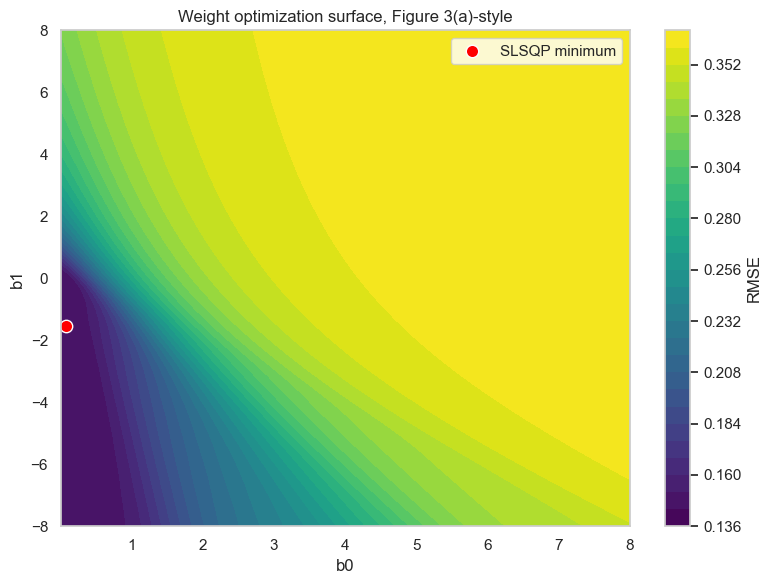

In [4]:
def standardize_01(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmin(x)) / max(float(np.nanmax(x) - np.nanmin(x)), 1e-9)


def fusion_from_params(b0, b1):
    sigma = np.clip(standardize_01(kr_var), 1e-9, 1.0)
    z_scaled = standardize_01(kr_pred)
    b = np.clip(b0 + b1 * z_scaled, 0.01, 8.0)
    w = np.clip(sigma ** b, 0, 1)
    return w * ml_pred + (1 - w) * kr_pred, w


def objective(params):
    pred, _ = fusion_from_params(params[0], params[1])
    return mean_squared_error(y_test, pred) ** 0.5

opt_result = minimize(
    objective,
    x0=np.array([1.0, 0.0]),
    method='SLSQP',
    bounds=[(0.01, 8.0), (-8.0, 8.0)],
    options={'maxiter': 300, 'ftol': 1e-9},
)
best_b0, best_b1 = opt_result.x
best_pred, best_w = fusion_from_params(best_b0, best_b1)
print({'success': opt_result.success, 'message': opt_result.message, 'best_b0': best_b0, 'best_b1': best_b1, 'best_rmse': opt_result.fun})

b0_grid = np.linspace(0.01, 8.0, 90)
b1_grid = np.linspace(-8.0, 8.0, 90)
loss = np.zeros((len(b1_grid), len(b0_grid)))
for i, b1 in enumerate(b1_grid):
    for j, b0 in enumerate(b0_grid):
        pred, _ = fusion_from_params(b0, b1)
        loss[i, j] = mean_squared_error(y_test, pred) ** 0.5

plt.figure(figsize=(8, 6))
contour = plt.contourf(b0_grid, b1_grid, loss, levels=30, cmap='viridis')
plt.colorbar(contour, label='RMSE')
plt.scatter([best_b0], [best_b1], c='red', s=80, edgecolor='white', label='SLSQP minimum')
plt.xlabel('b0')
plt.ylabel('b1')
plt.title('Weight optimization surface, Figure 3(a)-style')
plt.legend()
plt.tight_layout()


## 5. 比較 Final Models

final comparison 會列出 RMSE、MAE 與 R²。這張表可以放進期末報告，用來說明 combined model 是否比 ordinary Kriging 有更好的預測表現。

,model,RMSE,MAE,R2
0,Ordinary Kriging,0.365743,0.312855,0.748119
1,Super Learner,0.145912,0.105957,0.959911
2,Optimized Fusion,0.145042,0.104824,0.960388


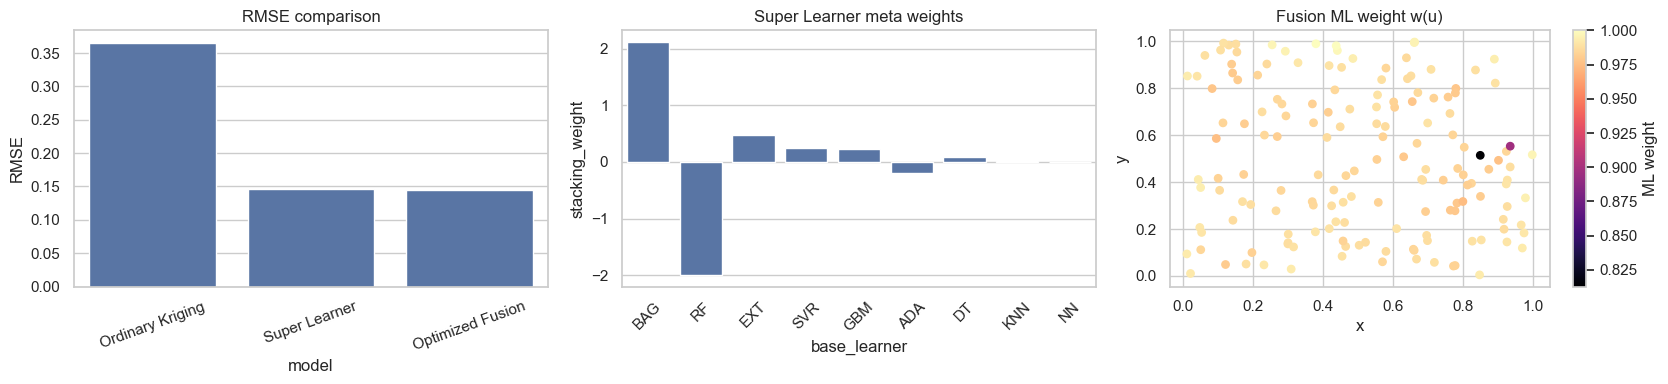

In [5]:
final_results = pd.DataFrame([
    metric_row('Ordinary Kriging', kr_pred),
    metric_row('Super Learner', ml_pred),
    metric_row('Optimized Fusion', best_pred),
])
display(final_results)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.barplot(data=final_results, x='model', y='RMSE', ax=axes[0])
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_title('RMSE comparison')
sns.barplot(data=meta_weights, x='base_learner', y='stacking_weight', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Super Learner meta weights')
sc = axes[2].scatter(test['x'], test['y'], c=best_w, cmap='magma', s=28)
axes[2].set_title('Fusion ML weight w(u)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
plt.colorbar(sc, ax=axes[2], label='ML weight')
plt.tight_layout()
